In [10]:
import pandas as pd

df_2020 = pd.read_csv('data/processed/agosto2020.csv')
df_2024 = pd.read_csv('data/processed/agosto2024.csv')
df_2020['date'] = pd.to_datetime(df_2020['date'])
df_2024['date'] = pd.to_datetime(df_2024['date'])
# Creamos la columna 'Año' para diferenciar los periodos tras la fusión
df_2020 = df_2020[df_2020['date'].dt.month == 8]
df_2024 = df_2024[df_2024['date'].dt.month == 8]
df_2020['Año'] = '2020'
df_2024['Año'] = '2024'

# "Apilamos" un dataframe sobre el otro
df_comparativo = pd.concat([df_2020, df_2024], ignore_index=True)

df_comparativo

,date,CO,O3,NO,NO2,PM2.5,NOX,PM10,SO2,WSR,WDR,Zona,Hora,Año
0,2020-08-01 00:00:00,2.255,40.0,1.3,1.8,24.135,3.1,40.935,2.65,3.4,92.0,CENTRO,0,2020
1,2020-08-01 01:00:00,2.220,22.0,1.5,2.2,20.030,3.7,46.740,2.60,5.0,56.0,CENTRO,1,2020
2,2020-08-01 02:00:00,2.190,19.0,2.3,2.4,20.580,4.7,51.640,2.60,2.8,57.0,CENTRO,2,2020
3,2020-08-01 03:00:00,2.210,14.0,2.7,2.6,22.970,5.3,53.630,2.58,1.2,182.0,CENTRO,3,2020
4,2020-08-01 04:00:00,2.250,13.0,2.0,2.5,22.720,4.5,47.130,2.56,5.1,25.0,CENTRO,4,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1483,2024-08-31 19:00:00,1.000,28.0,2.2,11.3,11.400,13.7,33.000,3.30,7.2,121.0,CENTRO,19,2024
1484,2024-08-31 20:00:00,1.090,16.0,2.1,17.7,11.670,19.9,35.000,3.30,4.6,102.0,CENTRO,20,2024
1485,2024-08-31 21:00:00,1.120,10.0,2.7,18.7,12.210,21.5,43.000,3.40,1.9,308.0,CENTRO,21,2024
1486,2024-08-31 22:00:00,1.110,13.0,2.8,15.0,12.020,17.9,47.000,3.30,3.2,75.0,CENTRO,22,2024


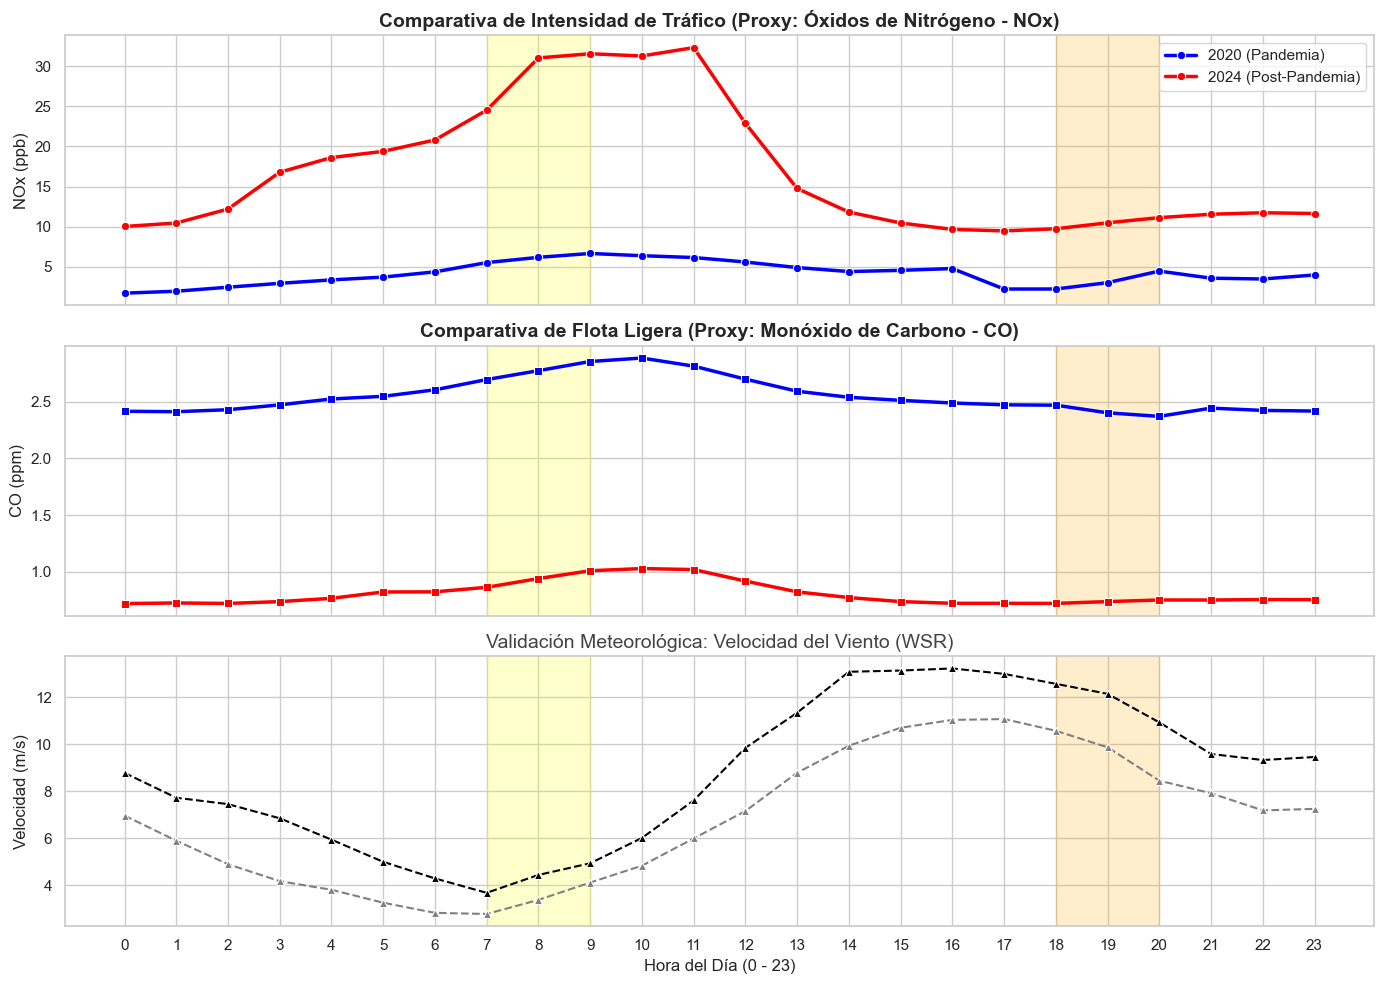

--- Validación Meteorológica ---
Viento Promedio Agosto 2020: 6.79 m/s
Viento Promedio Agosto 2024: 8.77 m/s
Diferencia porcentual: 29.2%
ALERTA: Hay una diferencia significativa en el viento. Parte del cambio en la contaminación es meteorológico.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)


#Agrupación por Hora (El "Ciclo Diurno")
# Calculamos el promedio de cada contaminante y del viento para cada hora del día (0-23)
perfil_horario_2020 = df_2020.groupby('Hora')[['NOX', 'CO', 'WSR']].mean().reset_index()
perfil_horario_2024 = df_2024.groupby('Hora')[['NOX', 'CO', 'WSR']].mean().reset_index()

# Añadimos etiqueta de año para facilitar el ploteo conjunto
perfil_horario_2020['Año'] = '2020 (Pandemia)'
perfil_horario_2024['Año'] = '2024 (Post-Pandemia)'

# Unimos los perfiles horarios en un solo dataset para graficar
df_perfiles = pd.concat([perfil_horario_2020, perfil_horario_2024])

# 4. Visualización Multivariada
fig, axes = plt.subplots(3, 1, sharex=True)

# Gráfica A: NOx (Trazador principal de Tráfico Diésel/Pesado y total)
sns.lineplot(data=df_perfiles, x='Hora', y='NOX', hue='Año', marker='o', palette=['blue', 'red'], ax=axes[0], linewidth=2.5)
axes[0].set_title('Comparativa de Intensidad de Tráfico (Proxy: Óxidos de Nitrógeno - NOx)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('NOx (ppb)')
axes[0].legend(loc='upper right')

# Gráfica B: CO (Trazador de Autos Gasolina)
sns.lineplot(data=df_perfiles, x='Hora', y='CO', hue='Año', marker='s', palette=['blue', 'red'], ax=axes[1], linewidth=2.5)
axes[1].set_title('Comparativa de Flota Ligera (Proxy: Monóxido de Carbono - CO)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('CO (ppm)')
axes[1].legend().remove() # Removemos leyenda redundante



# Gráfica C: WSR (Validación Meteorológica)
sns.lineplot(data=df_perfiles, x='Hora', y='WSR', hue='Año', marker='^', palette=['gray', 'black'], linestyle='--', ax=axes[2])
axes[2].set_title('Validación Meteorológica: Velocidad del Viento (WSR)', fontsize=14, color='#444444')
axes[2].set_ylabel('Velocidad (m/s)')
axes[2].set_xlabel('Hora del Día (0 - 23)')
axes[2].set_xticks(range(0, 24)) # Asegurar que se vean todas las horas
axes[2].legend().remove()

# Añadir áreas sombreadas para las "Horas Pico" (Rush Hour)
for ax in axes:
    ax.axvspan(7, 9, color='yellow', alpha=0.2, label='Hora Pico Mañana')
    ax.axvspan(18, 20, color='orange', alpha=0.2, label='Hora Pico Tarde')

plt.tight_layout()
plt.show()

# 5. Cálculo Numérico de la Validación
viento_prom_2020 = df_2020['WSR'].mean()
viento_prom_2024 = df_2024['WSR'].mean()
diff_viento = ((viento_prom_2024 - viento_prom_2020) / viento_prom_2020) * 100

print(f"--- Validación Meteorológica ---")
print(f"Viento Promedio Agosto 2020: {viento_prom_2020:.2f} m/s")
print(f"Viento Promedio Agosto 2024: {viento_prom_2024:.2f} m/s")
print(f"Diferencia porcentual: {diff_viento:.1f}%")

if abs(diff_viento) < 15:
    print("CONCLUSIÓN: Las condiciones de dispersión fueron similares. El cambio en contaminantes es atribuible al TRÁFICO.")
else:
    print("ALERTA: Hay una diferencia significativa en el viento. Parte del cambio en la contaminación es meteorológico.")

<Figure size 1000x600 with 0 Axes>

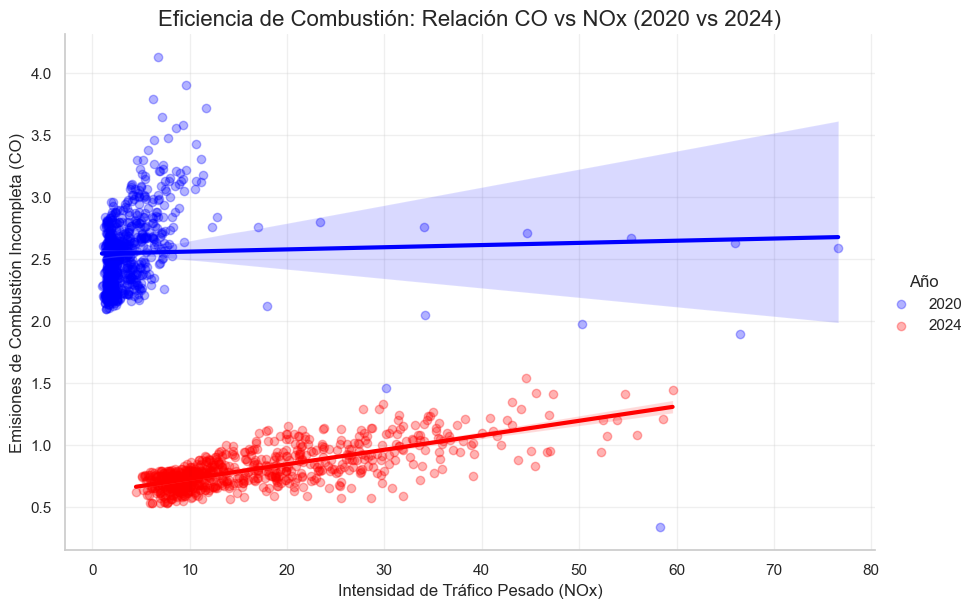

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Usamos el dataframe 'df_comparativo' que creamos antes
plt.figure(figsize=(10, 6))

# Gráfico de dispersión con líneas de tendencia
sns.lmplot(data=df_comparativo, x="NOX", y="CO", hue="Año", 
           scatter_kws={'alpha':0.3}, line_kws={'linewidth': 3},
           palette=['blue', 'red'], height=6, aspect=1.5)

plt.title("Eficiencia de Combustión: Relación CO vs NOx (2020 vs 2024)", fontsize=16)
plt.xlabel("Intensidad de Tráfico Pesado (NOx)", fontsize=12)
plt.ylabel("Emisiones de Combustión Incompleta (CO)", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

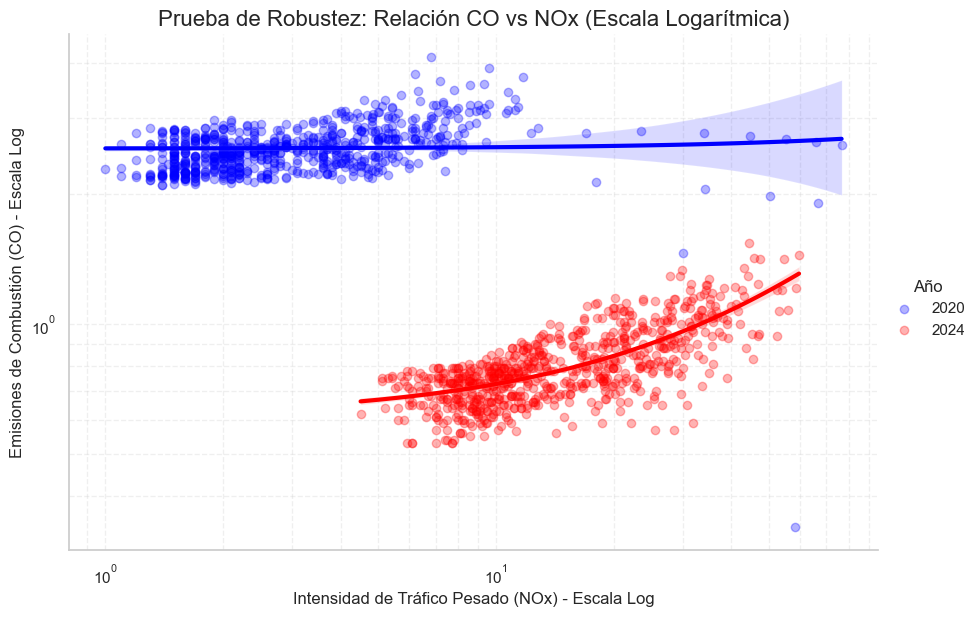

------------------------------
Elasticidad 2020 (Pendiente Log-Log): 0.0485
Elasticidad 2024 (Pendiente Log-Log): 0.2429
------------------------------
Interpretación: Un valor más bajo indica una relación más débil o una base de emisiones distinta.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression


# IMPORTANTE: Filtramos valores <= 0 porque el logaritmo de 0 o negativos no existe
df_comparativo = df_comparativo[(df_comparativo['NOX'] > 0) & (df_comparativo['CO'] > 0)]

# --- 2. Generación de la Gráfica Log-Log ---
# Usamos lmplot que hace el scatter y la línea de regresión automáticamente
g = sns.lmplot(data=df_comparativo, x="NOX", y="CO", hue="Año", 
               scatter_kws={'alpha':0.3}, # Transparencia para ver la densidad de puntos
               line_kws={'linewidth': 3}, # Líneas de tendencia más gruesas
               palette=['blue', 'red'], 
               height=6, aspect=1.5)

# Aquí está el TRUCO: cambiamos la escala de los ejes a logarítmica
g.set(xscale="log", yscale="log")

# Decoración de la gráfica
plt.title("Prueba de Robustez: Relación CO vs NOx (Escala Logarítmica)", fontsize=16)
plt.xlabel("Intensidad de Tráfico Pesado (NOx) - Escala Log", fontsize=12)
plt.ylabel("Emisiones de Combustión (CO) - Escala Log", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()

# --- 3. Cálculo de la Elasticidad (Pendiente Log-Log) ---
def get_log_slope(df):
    """Calcula la pendiente de la regresión sobre los logaritmos de los datos"""
    # Filtro de seguridad interno
    df_clean = df[(df['NOX'] > 0) & (df['CO'] > 0)]
    
    # Transformación logarítmica (np.log es logaritmo natural)
    X_log = np.log(df_clean[['NOX']].values)
    y_log = np.log(df_clean['CO'].values)
    
    # Ajuste del modelo lineal
    model = LinearRegression()
    model.fit(X_log, y_log)
    return model.coef_[0]

# Aplicamos la función a cada año por separado
elasticidad_2020 = get_log_slope(df_2020)
elasticidad_2024 = get_log_slope(df_2024)

print("-" * 30)
print(f"Elasticidad 2020 (Pendiente Log-Log): {elasticidad_2020:.4f}")
print(f"Elasticidad 2024 (Pendiente Log-Log): {elasticidad_2024:.4f}")
print("-" * 30)
print("Interpretación: Un valor más bajo indica una relación más débil o una base de emisiones distinta.")